In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as mcm
import matplotlib.colors as mcolors
from pathlib import Path

In [30]:
# ----------- Paths -----------
TESTING_METRICS_DIR = Path("../../2_final_runs/3_uy_basins/ensemble_testing_metrics")
PEAK_METRICS_DIR    = Path("../../2_final_runs/3_uy_basins/ensemble_peak_metrics")

In [31]:
# UY
run_configs = [
    ('CARAVAN',             'precip_prcp_mm_day'),
    ('CHIRPS',              'precip_prcp_chirps_mm_day'),
    ('MSWEP',               'precip_prcp_mswep_mm_day'),
    ('GAUGES',              'precip_prcp_gauge_mm_day'),
    ('CHIRPS\nMSWEP',       'precip_prcp_chirps_mm_day_prcp_mswep_mm_day'),
    ('CHIRPS\nGAUGES',      'precip_prcp_chirps_mm_day_prcp_gauge_mm_day'),
    ('MSWEP\nGAUGES',       'precip_prcp_mswep_mm_day_prcp_gauge_mm_day'),
    ('CHIRPS\nMSWEP\nGAUGES','precip_prcp_chirps_mm_day_prcp_mswep_mm_day_prcp_gauge_mm_day'),
]

labels      = [label for label, _ in run_configs]
run_metrics = [run   for _, run   in run_configs]

/tmp/ipykernel_5894/1073307067.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(nse_data, labels=labels, showfliers=True)


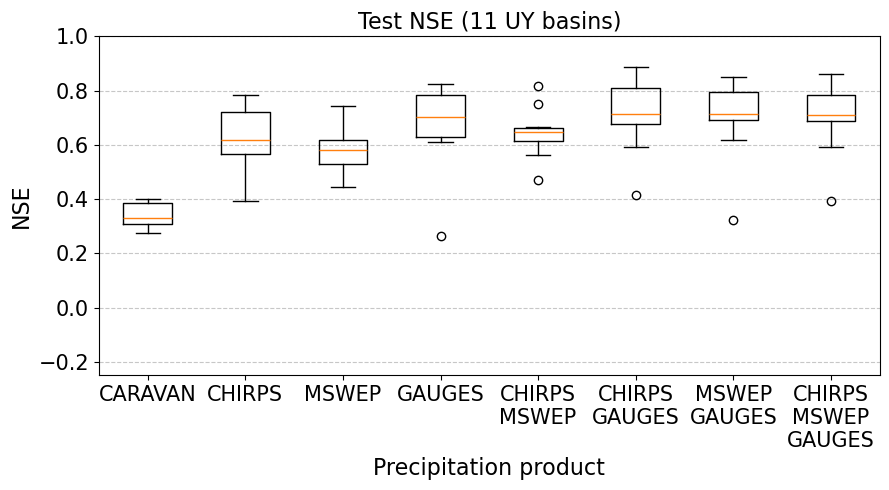

In [32]:
nse_data = []

for run in run_metrics:
    df = pd.read_csv(TESTING_METRICS_DIR / f"{run}.csv")
    nse_data.append(df["NSE"].dropna().values)

plt.figure(figsize=(9, 5))
plt.boxplot(nse_data, labels=labels, showfliers=True)

plt.ylabel("NSE", fontsize=16)
plt.xlabel("Precipitation product", fontsize=16)
plt.title("Test NSE (11 UY basins)", fontsize=16)

# For poster
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.ylim(-0.25,1)  # NSE is typically ≤ 1
plt.tight_layout()
plt.grid(axis = 'y', linestyle='--', alpha=0.7)
plt.show()

In [33]:
metrics_to_plot = ['FHV', 'FMS', 'FLV']

# --- load all data ---
all_metrics = {m: [] for m in metrics_to_plot}

for run in run_metrics:
    df   = pd.read_csv(TESTING_METRICS_DIR / f"{run}.csv")

    for m in metrics_to_plot:
        all_metrics[m].append(df[m].values)

/tmp/ipykernel_5894/3341435565.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')
/tmp/ipykernel_5894/3341435565.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')
/tmp/ipykernel_5894/3341435565.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('RdBu')


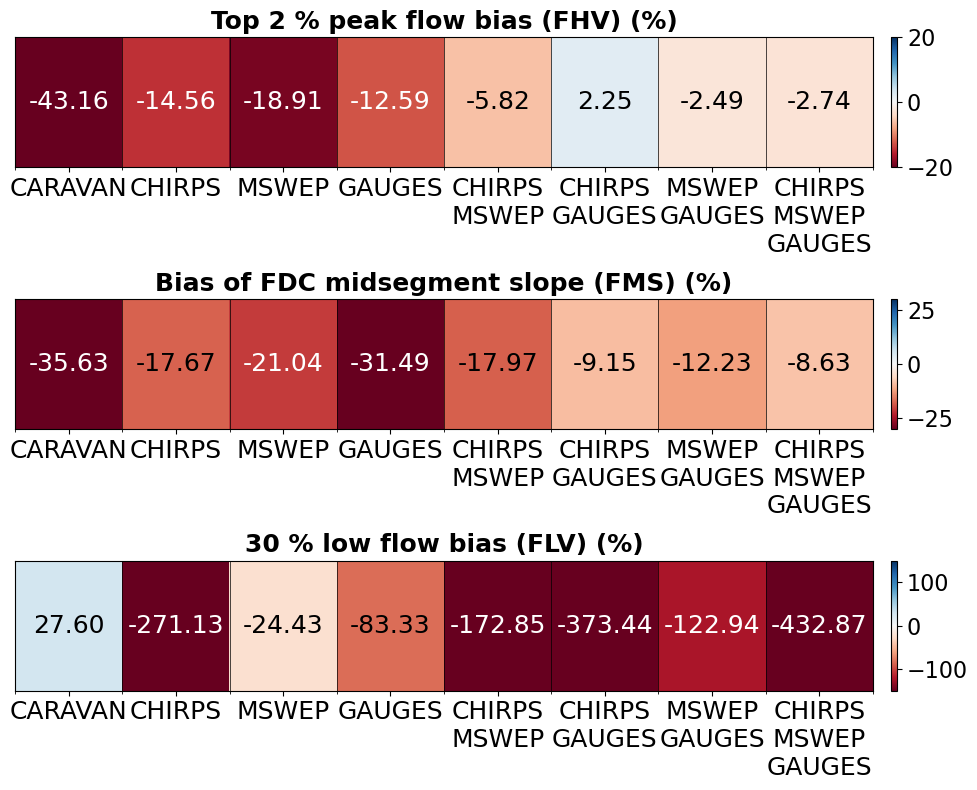

In [34]:
metric_limits = {
    'FHV': (-20, 20),
    'FMS': (-30, 30),
    'FLV': (-150, 150),
}

metric_title = {
    'FHV': 'Top 2 % peak flow bias (FHV) (%)',
    'FMS': 'Bias of FDC midsegment slope (FMS) (%)',
    'FLV': '30 % low flow bias (FLV) (%)',
}

# fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(9, 9))
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 8))

for ax, metric in zip(axes, metrics_to_plot):

    # median per dataset
    medians = np.array([np.nanmedian(values) for values in all_metrics[metric]])
    data_2d = medians.reshape(1, -1)

    vmin, vmax = metric_limits[metric]
    cmap = mcm.get_cmap('RdBu')
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    im = ax.imshow(data_2d, aspect='auto', cmap=cmap, norm=norm)

    ax.set_xlim(-0.5, len(medians) - 0.5)

    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    for j, val in enumerate(medians):
        rgba = cmap(norm(val))
        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = 'black' if brightness > 0.5 else 'white'

        ax.text(
            j, 0,
            f"{val:.2f}",
            ha='center',
            va='center',
            fontsize=18,
            color=text_color
        )

    ax.set_title(metric_title[metric], fontsize=18, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=18)
    ax.set_xticks(np.arange(-0.5, len(medians), 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [35]:
metrics_to_plot = ['Peak-Timing', 'Missed-Peaks', 'Peak-MAPE']

all_metrics = {m: [] for m in metrics_to_plot}

for run in run_metrics:
    df   = pd.read_csv(TESTING_METRICS_DIR / f"{run}.csv")
    df_2 = pd.read_csv(PEAK_METRICS_DIR    / f"{run}.csv")

    for m in metrics_to_plot:
        source = df if m == 'Peak-MAPE' else df_2
        all_metrics[m].append(source[m].values)

/tmp/ipykernel_5894/183311009.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')
/tmp/ipykernel_5894/183311009.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')
/tmp/ipykernel_5894/183311009.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mcm.get_cmap('Reds')


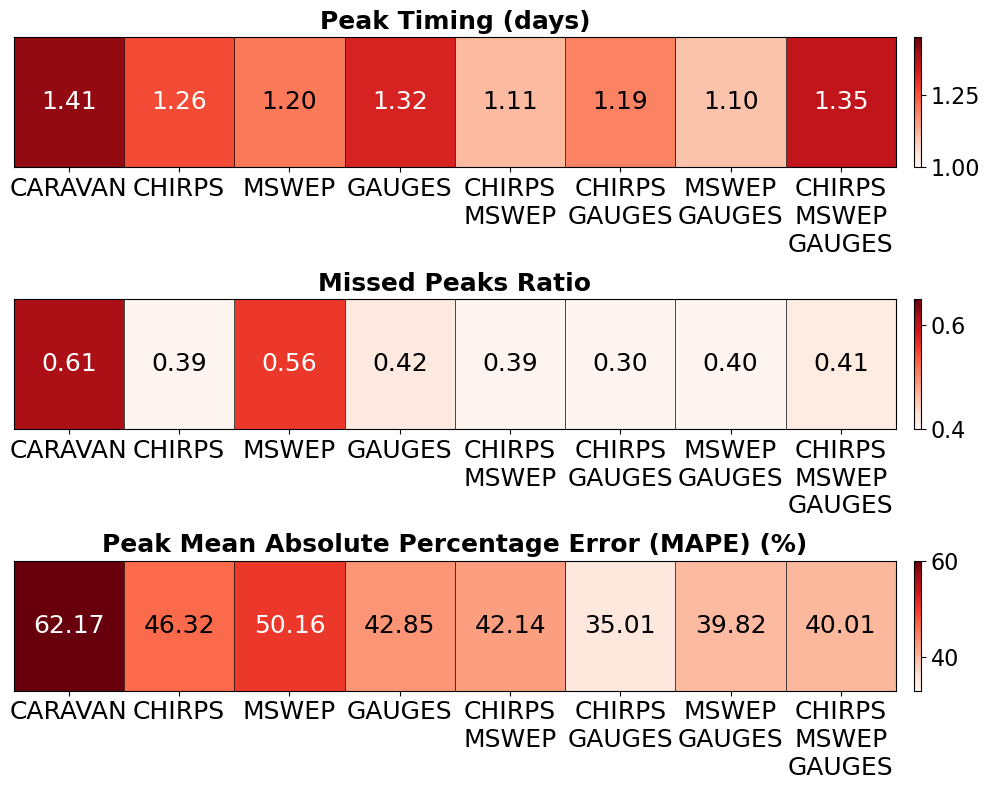

In [36]:
metric_limits = {
    'Peak-Timing':  (1, 1.45),
    'Missed-Peaks': (0.4, 0.65),
    'Peak-MAPE':    (33,   60),
}

metric_title = {
    'Peak-Timing':  'Peak Timing (days)',
    'Missed-Peaks': 'Missed Peaks Ratio',
    'Peak-MAPE':    'Peak Mean Absolute Percentage Error (MAPE) (%)',
}

# fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(9, 9))
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(10, 8))

for ax, metric in zip(axes, metrics_to_plot):

    # median per dataset (same structure as before)
    medians = np.array([np.nanmedian(values) for values in all_metrics[metric]])
    data_2d = medians.reshape(1, -1)

    vmin, vmax = metric_limits[metric]

    cmap = mcm.get_cmap('Reds')
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    im = ax.imshow(data_2d, aspect='auto', cmap=cmap, norm=norm)
    
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlim(-0.5, len(medians) - 0.5)

    cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    for j, val in enumerate(medians):
        rgba = cmap(norm(val))
        brightness = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = 'black' if brightness > 0.5 else 'white'

        ax.text(
            j, 0,
            f"{val:.2f}",
            ha='center',
            va='center',
            fontsize=18,
            color=text_color
        )

    ax.set_title(metric_title[metric], fontsize=18, fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=18)

    for j in range(len(medians) - 1):
        ax.axvline(j + 0.5, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()